# Inspect ESMDynamic's released weights by hand

This notebook lets you check, on your own laptop (CPU only, no GPU, no ESMDynamic install), the claims in
`investigation/EVIDENCE.md`:

| § | check | what you should see if the blocks never trained |
|---|---|---|
| 1 | the file is the official V2 release | sha256 `b41a1a22e9afd664…` |
| 2 | what is in the file | 3 heads; ~28.6 M of each head's ~32 M parameters sit inside 2 Evoformer blocks |
| 3 | one block, tensor by tensor | every tensor is exactly 0, exactly 1, or random |
| 4 | are the random ones still at their initial distribution? | spread and shape match the initializer's formula (KS test) |
| 5 | histograms: block matrix vs a fresh initialization vs a trained layer | block = fresh init; trained layer looks different |
| 6 | the blocks' output layers | all exactly 0, in all 6 blocks |
| 7 | run the blocks' arithmetic with the real weights | inner activations nonzero, update added to the input exactly 0 |
| 8 | the parts around the blocks | most trained; recycling-distance embedding uses only row 0 |
| 9 | the V1 release (optional) | same picture |
| 10 | **the cause**, live: PyTorch autocast + `no_grad` recycling | weight gradient `None` with the cache on, real with it off |

**Kernel:** any Python with `torch`, `numpy`, `pandas`, `scipy`, `matplotlib`. On this laptop that is the
`default` conda env (torch 2.8, the version ESMDynamic pins), registered as the Jupyter kernel
**"Python (esmdynamic-inspect)"**.

**Files:** set the paths in the next cell. The V2 weights are what `esm.pretrained.esmdynamic()` loads
(Illinois Data Bank datafile `7odsk`).

In [1]:
from pathlib import Path
import hashlib, math
import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as F
from scipy import stats
import matplotlib.pyplot as plt

V2_PATH = Path.home() / "Downloads/esmdynamic_model_weights_V2.pt"          # the released V2 file
V1_PATH = Path.home() / "disco_lab/rescued_from_cluster_2026-10-07/esmdynamic_V1.pt"   # optional, §9
REPO = Path.cwd().resolve().parents[1] if Path.cwd().name == "notebooks" else Path.cwd()  # esmdynamic repo root

pd.set_option("display.max_rows", 200); pd.set_option("display.width", 160)
torch.set_grad_enabled(False)
print("torch", torch.__version__, "| V2 file exists:", V2_PATH.exists(), "| V1 file exists:", V1_PATH.exists())
print("repo root:", REPO, "| dynamic_module.py found:", (REPO / "esm/esmdynamic/dynamic_module.py").exists())

torch 2.8.0 | V2 file exists: True | V1 file exists: True
repo root: /Users/smadejski/disco_lab/github/esmdynamic | dynamic_module.py found: True


## 1. Is this the official file?

Every public route (the `esm.pretrained.esmdynamic()` loader, `run_esmdynamic`, the Dockerfile, the Colab notebook)
downloads the same file. Its checksum identifies it.

In [2]:
h = hashlib.sha256()
with open(V2_PATH, "rb") as f:
    for chunk in iter(lambda: f.read(1 << 20), b""):
        h.update(chunk)
print("size  ", V2_PATH.stat().st_size, "bytes (expected 383,731,643)")
print("sha256", h.hexdigest())
print("PASS: official V2 release" if h.hexdigest().startswith("b41a1a22e9afd664") else "MISMATCH: not the V2 release")

size   383731643 bytes (expected 383,731,643)
sha256 b41a1a22e9afd6641ca2fa39a4c183230605ff6b92de3cbb31e2f6928e007475
PASS: official V2 release


## 2. What is in the file

The file is a dictionary from parameter names to tensors. Names look like
`heads.<head>.dynamic_module.blocks.<i>.<layer>.weight`. Only the three heads are stored; ESMFold itself
(frozen, from Meta) is loaded separately.

In [3]:
sd = torch.load(V2_PATH, map_location="cpu", weights_only=False)
sd = sd.get("model", sd)
sd = {k: v.float() for k, v in sd.items()}
HEADS = sorted({k.split(".")[1] for k in sd if k.startswith("heads.")})

def head_params(h, in_blocks):
    return sum(v.numel() for k, v in sd.items()
               if k.startswith(f"heads.{h}.") and ((".blocks." in k) == in_blocks))

rows = [{"head": h, "params inside the 2 blocks": head_params(h, True),
         "params outside the blocks": head_params(h, False)} for h in HEADS]
df = pd.DataFrame(rows); df["share inside blocks"] = (df.iloc[:, 1] / (df.iloc[:, 1] + df.iloc[:, 2])).map("{:.0%}".format)
print(len(sd), "tensors in total;", sum(v.numel() for v in sd.values()), "parameters")
df

558 tensors in total; 95894843 parameters


,head,params inside the 2 blocks,params outside the blocks,share inside blocks
0,dynamic,28587776,3548332,89%
1,frequency,28587776,3027756,90%
2,kinetic,28587776,3555427,89%


## 3. One block, tensor by tensor

A block (`TriangularSelfAttentionBlock`, the Evoformer block ESMFold also uses) has 80 tensors. Classify each:

- **exactly 0** — e.g. output layers, which are zero-initialised so a new block starts as the identity
- **exactly 1** — LayerNorm scales and gate biases start at 1
- **random** — everything else starts random

A trained tensor would be none of the first two and would have drifted from its random start (§4).

In [4]:
def kind(v):
    if torch.count_nonzero(v) == 0: return "exactly 0"
    if torch.equal(v, torch.ones_like(v)): return "exactly 1"
    return "random"

prefix = "heads.dynamic.dynamic_module.blocks.0."
block0 = {k[len(prefix):]: v for k, v in sd.items() if k.startswith(prefix)}
t = pd.DataFrame([{"tensor": k, "shape": tuple(v.shape), "kind": kind(v),
                   "mean": v.mean().item(), "std": v.std().item() if v.numel() > 1 else 0.0}
                  for k, v in block0.items()])
print(t["kind"].value_counts().to_string())
t

kind
exactly 0    42
exactly 1    20
random       18


,tensor,shape,kind,mean,std
0,layernorm_1.weight,"(1024,)",exactly 1,1.000000,0.000000
1,layernorm_1.bias,"(1024,)",exactly 0,0.000000,0.000000
2,sequence_to_pair.layernorm.weight,"(1024,)",exactly 1,1.000000,0.000000
3,sequence_to_pair.layernorm.bias,"(1024,)",exactly 0,0.000000,0.000000
4,sequence_to_pair.proj.weight,"(128, 1024)",random,-0.000004,0.018037
5,sequence_to_pair.proj.bias,"(128,)",exactly 0,0.000000,0.000000
6,sequence_to_pair.o_proj.weight,"(128, 128)",exactly 0,0.000000,0.000000
7,sequence_to_pair.o_proj.bias,"(128,)",exactly 0,0.000000,0.000000
8,pair_to_sequence.layernorm.weight,"(128,)",exactly 1,1.000000,0.000000
9,pair_to_sequence.layernorm.bias,"(128,)",exactly 0,0.000000,0.000000


## 4. Are the random tensors still at their initial distribution?

Two initializers are used inside a block:

- **PyTorch's default `nn.Linear` init** (the ESM-style layers: `seq_attention`, `sequence_to_pair`, `mlp_*`):
  uniform on ±1/√fan_in, so std = 1/√(3·fan_in).
- **openfold's LeCun normal** (the triangle layers): std = 1/√fan_in.

For each random tensor we compare its std with each formula, and run a Kolmogorov–Smirnov test of its values
against the matching distribution. **At initialisation, the std ratio is ≈ 1.00 and the KS test does not
reject.** Training moves weights away from these exact distributions; §5 shows a trained layer for contrast.

In [5]:
def init_test(v, fan_in):
    x = v.flatten().numpy()
    if len(x) > 200_000:                      # KS on a random subsample: same answer, faster
        x = np.random.default_rng(0).choice(x, 200_000, replace=False)
    b = 1 / math.sqrt(fan_in)
    s_unif, s_lecun = b / math.sqrt(3), b
    r_u, r_l = v.std().item() / s_unif, v.std().item() / s_lecun
    if abs(r_u - 1) < abs(r_l - 1):
        p = stats.kstest(x, stats.uniform(loc=-b, scale=2 * b).cdf).pvalue
        return "default uniform", r_u, p, x.min() >= -b - 1e-7 and x.max() <= b + 1e-7
    p = stats.kstest(x, stats.norm(scale=s_lecun).cdf).pvalue          # openfold truncates at ±2σ; see note
    return "LeCun normal", r_l, p, True

rows = []
for h in HEADS:
    for i in (0, 1):
        pre = f"heads.{h}.dynamic_module.blocks.{i}."
        for k, v in sd.items():
            if not k.startswith(pre) or kind(v) != "random":
                continue
            name = k[len(pre):]
            if v.dim() == 2:
                fan_in = v.shape[1]
            else:                                    # a bias: fan_in from its weight matrix
                fan_in = sd[k[:-len("bias")] + "weight"].shape[1]
            init, ratio, p, in_bounds = init_test(v, fan_in)
            rows.append({"head": h, "block": i, "tensor": name, "n": v.numel(), "matches": init,
                         "std / formula": round(ratio, 4), "KS p": p, "within ±1/√fan_in": in_bounds})
r = pd.DataFrame(rows)
print(f"{len(r)} random tensors across 6 blocks")
print("std / formula:  min %.4f  max %.4f   (1.0000 = exactly the initializer's spread)" % (r['std / formula'].min(), r['std / formula'].max()))
print("default-uniform tensors all within the uniform bounds:", bool(r.loc[r.matches == 'default uniform', 'within ±1/√fan_in'].all()))
r.sort_values("std / formula")

108 random tensors across 6 blocks
std / formula:  min 0.9613  max 1.0566   (1.0000 = exactly the initializer's spread)
default-uniform tensors all within the uniform bounds: True


,head,block,tensor,n,matches,std / formula,KS p,within ±1/√fan_in
82,kinetic,0,tri_att_end.linear.weight,512,LeCun normal,0.9613,3.275093e-01,True
60,frequency,1,tri_att_start.linear.weight,512,LeCun normal,0.9673,7.002202e-02,True
6,dynamic,0,tri_att_start.linear.weight,512,LeCun normal,0.9676,9.573540e-01,True
100,kinetic,1,tri_att_end.linear.weight,512,LeCun normal,0.9679,6.180699e-01,True
89,kinetic,0,mlp_pair.mlp.1.bias,512,default uniform,0.9805,1.592651e-01,True
20,dynamic,1,tri_mul_out.linear_a_p.weight,16384,LeCun normal,0.9901,1.814720e-03,True
107,kinetic,1,mlp_pair.mlp.1.bias,512,default uniform,0.9902,8.075506e-01,True
58,frequency,1,tri_mul_in.linear_a_p.weight,16384,LeCun normal,0.9906,1.833130e-04,True
69,frequency,1,mlp_seq.mlp.1.bias,4096,default uniform,0.9914,3.484157e-01,True
87,kinetic,0,mlp_seq.mlp.1.bias,4096,default uniform,0.9920,5.139711e-02,True


*Note on the LeCun-normal tensors:* openfold draws them from a normal truncated at ±2σ and rescaled so the std
is exactly 1/√fan_in. A plain-normal KS test can therefore show small p-values for these on large matrices even
though they are untouched; the std ratio of ≈ 1.00 is the reliable signal. The uniform ones are a sharper test:
every value lies inside ±1/√fan_in, which training would break.

## 5. Look at it: block weights vs a fresh initialization vs a trained layer

Left: one of the block's attention input matrices. Middle: a brand-new `nn.Linear` of the same shape, made
right now. Right: the head's trained pair-transition matrix, which started from the same kind of uniform box.

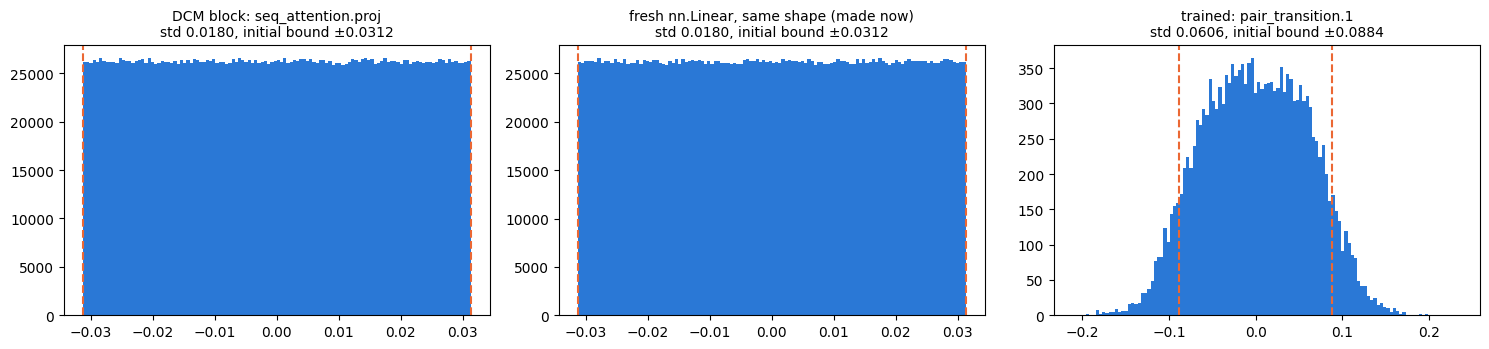

fraction of the trained matrix outside its initial bound: 14.3%
fraction of the block matrix outside its initial bound:   0.0%


In [6]:
blk = sd["heads.dynamic.dynamic_module.blocks.0.seq_attention.proj.weight"]
fresh = nn.Linear(blk.shape[1], blk.shape[0]).weight.detach()
trained = sd["heads.dynamic.pair_transition.1.weight"]
b_tr = 1 / math.sqrt(trained.shape[1])

fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
for a, w, title, b in ((ax[0], blk, "DCM block: seq_attention.proj", 1 / math.sqrt(blk.shape[1])),
                       (ax[1], fresh, "fresh nn.Linear, same shape (made now)", 1 / math.sqrt(blk.shape[1])),
                       (ax[2], trained, "trained: pair_transition.1", b_tr)):
    a.hist(w.flatten().numpy(), bins=120, color="#2a78d6")
    a.axvline(-b, color="#eb6834", ls="--"); a.axvline(b, color="#eb6834", ls="--")
    a.set_title(f"{title}\nstd {w.std():.4f}, initial bound ±{b:.4f}", fontsize=10)
plt.tight_layout(); plt.show()
print("fraction of the trained matrix outside its initial bound:", f"{(trained.abs() > b_tr).float().mean():.1%}")
print("fraction of the block matrix outside its initial bound:  ", f"{(blk.abs() > 1/math.sqrt(blk.shape[1])).float().mean():.1%}")

## 6. The blocks' output layers

Every path through a block ends in an output layer whose result is **added** to the block's input. These layers
start at zero. In a trained Evoformer (ESMFold's own trunk) their norms are 23–256 (job 2079787).

In [7]:
OUTPUT_LAYERS = ["seq_attention.o_proj", "sequence_to_pair.o_proj", "pair_to_sequence.linear", "mlp_seq.mlp.3", "mlp_pair.mlp.3",
                 "tri_mul_out.linear_z", "tri_mul_in.linear_z", "tri_att_start.mha.linear_o", "tri_att_end.mha.linear_o"]
rows = []
for h in HEADS:
    for i in (0, 1):
        for L in OUTPUT_LAYERS:
            w = sd[f"heads.{h}.dynamic_module.blocks.{i}.{L}.weight"]
            bkey = f"heads.{h}.dynamic_module.blocks.{i}.{L}.bias"
            rows.append({"head": h, "block": i, "layer": L, "weight norm": w.norm().item(),
                         "bias norm": sd[bkey].norm().item() if bkey in sd else None})
o = pd.DataFrame(rows)
print("largest output-layer weight norm in any block:", o["weight norm"].max())
print("PASS: every output layer is exactly zero" if o["weight norm"].max() == 0 else "some output layer is nonzero")
o.pivot_table(index=["head", "block"], columns="layer", values="weight norm")

largest output-layer weight norm in any block: 0.0
PASS: every output layer is exactly zero


layer            mlp_pair.mlp.3  mlp_seq.mlp.3  pair_to_sequence.linear  seq_attention.o_proj  sequence_to_pair.o_proj  tri_att_end.mha.linear_o  \
head      block                                                                                                                                    
dynamic   0                 0.0            0.0                      0.0                   0.0                      0.0                       0.0   
          1                 0.0            0.0                      0.0                   0.0                      0.0                       0.0   
frequency 0                 0.0            0.0                      0.0                   0.0                      0.0                       0.0   
          1                 0.0            0.0                      0.0                   0.0                      0.0                       0.0   
kinetic   0                 0.0            0.0                      0.0                   0.0                      0.0                       0.0   
          1                 0.0            0.0                      0.0                   0.0                      0.0                       0.0   

layer            tri_att_start.mha.linear_o  tri_mul_in.linear_z  tri_mul_out.linear_z  
head      block                                                                         
dynamic   0                             0.0                  0.0                   0.0  
          1                             0.0                  0.0                   0.0  
frequency 0                             0.0                  0.0                   0.0  
          1                             0.0                  0.0                   0.0  
kinetic   0                             0.0                  0.0                   0.0  
          1                             0.0                  0.0                   0.0

## 7. Run the block's arithmetic with the real weights

We can't build the full block without openfold, but each path is a few lines of PyTorch. Feed inputs at the
size ESMFold actually produces (per-residue state RMS ≈ 148, pair state RMS ≈ 19; job 2079787) and compute:

- the **inner activations** (real, nonzero: the block does compute something), and
- the **update** the path adds to its input (should be exactly 0).

The sequence MLP path is computed exactly as `ResidueMLP` does it (`esm/esmfold/v1/misc.py`):
`s + Linear₂(ReLU(Linear₁(LayerNorm(s))))`.

In [8]:
torch.manual_seed(0)
L = 76                                                   # ubiquitin-sized
s = torch.randn(1, L, 1024) * 148.0
z = torch.randn(1, L, L, 128) * 19.0
P = lambda name: sd["heads.dynamic.dynamic_module.blocks.0." + name]

def residue_mlp(x, pre, d):
    h = F.layer_norm(x, (d,), P(pre + ".mlp.0.weight"), P(pre + ".mlp.0.bias"))
    h = F.relu(F.linear(h, P(pre + ".mlp.1.weight"), P(pre + ".mlp.1.bias")))
    upd = F.linear(h, P(pre + ".mlp.3.weight"), P(pre + ".mlp.3.bias"))
    return h, upd

h_s, upd_s = residue_mlp(s, "mlp_seq", 1024)
h_z, upd_z = residue_mlp(z, "mlp_pair", 128)
print(f"sequence MLP: inner activations RMS {h_s.pow(2).mean().sqrt():.3f}, nonzero fraction {(h_s != 0).float().mean():.2f}"
      f"  ->  update max |.| = {upd_s.abs().max().item()}")
print(f"pair MLP:     inner activations RMS {h_z.pow(2).mean().sqrt():.3f}, nonzero fraction {(h_z != 0).float().mean():.2f}"
      f"  ->  update max |.| = {upd_z.abs().max().item()}")

# attention: q, k, v come from the (random) input projection; whatever attention produces, the gated output goes
# through o_proj. Gate = sigmoid(g_proj(x)) = sigmoid(0·x + 1) ≈ 0.731, a constant.
x = F.layer_norm(s, (1024,), P("layernorm_1.weight"), P("layernorm_1.bias"))
qkv = F.linear(x, P("seq_attention.proj.weight"))
gate = torch.sigmoid(F.linear(x, P("seq_attention.g_proj.weight"), P("seq_attention.g_proj.bias")))
any_attention_output = torch.randn_like(x) * 10          # stand-in: the conclusion holds for ANY attention output
upd_attn = F.linear(gate * any_attention_output, P("seq_attention.o_proj.weight"), P("seq_attention.o_proj.bias"))
print(f"attention:    q/k/v RMS {qkv.pow(2).mean().sqrt():.3f}; gate min/max {gate.min():.4f}/{gate.max():.4f} (constant)"
      f"  ->  update max |.| = {upd_attn.abs().max().item()}")

# every output layer, applied to anything, gives exactly zero
worst = max(F.linear(torch.randn(3, sd[f'heads.{h}.dynamic_module.blocks.{i}.{L_}.weight'].shape[1]) * 100,
                     sd[f'heads.{h}.dynamic_module.blocks.{i}.{L_}.weight'],
                     sd.get(f'heads.{h}.dynamic_module.blocks.{i}.{L_}.bias')).abs().max().item()
            for h in HEADS for i in (0, 1) for L_ in OUTPUT_LAYERS)
print("largest update from ANY output layer in ANY of the 6 blocks, inputs of size 100:", worst)

sequence MLP: inner activations RMS 0.409, nonzero fraction 0.50  ->  update max |.| = 0.0
pair MLP:     inner activations RMS 0.407, nonzero fraction 0.50  ->  update max |.| = 0.0
attention:    q/k/v RMS 0.578; gate min/max 0.7311/0.7311 (constant)  ->  update max |.| = 0.0
largest update from ANY output layer in ANY of the 6 blocks, inputs of size 100: 0.0


**Control: what a block that had learned even a little would do.** Set one output layer to tiny nonzero values
(1e-3), as in note 05's control, and the update stops being zero.

In [9]:
w_tiny = torch.full_like(P("mlp_seq.mlp.3.weight"), 1e-3)
upd_tiny = F.linear(h_s, w_tiny)
print(f"with mlp_seq.mlp.3 weights = 1e-3 instead of 0: update RMS {upd_tiny.pow(2).mean().sqrt():.3f}  (vs exactly 0 in the released file)")

with mlp_seq.mlp.3 weights = 1e-3 instead of 0: update RMS 0.946  (vs exactly 0 in the released file)


## 8. The parts around the blocks

Same test as §4, applied to everything in each head outside the blocks. LayerNorms count as trained if they moved
off exactly 1 / 0; other tensors if their spread differs from the initializer's by more than sampling error
(|z| > 4). Small tensors (a few dozen numbers) and embeddings, which start as random N(0, 1), are hard to
call either way; treat "statistically at init" there as "could not detect movement".

In [10]:
def expected_std(k, v):
    if "embedding" in k or "recycle_disto" in k: return 1.0                     # nn.Embedding: N(0, 1)
    if v.dim() == 2: return 1 / math.sqrt(3 * v.shape[1])
    w = sd.get(k.rsplit(".", 1)[0] + ".weight")
    if k.endswith(".bias") and w is not None and w.dim() == 2: return 1 / math.sqrt(3 * w.shape[1])
    return None                                                                  # LayerNorm

def verdict(k, v):
    if "recycle_disto" in k: v = v[1:]                                           # row 0 starts at 0; see below
    if torch.count_nonzero(v) == 0: return "at init (exactly 0)", None
    if torch.equal(v, torch.ones_like(v)): return "at init (exactly 1)", None
    e = expected_std(k, v)
    if e is None: return "TRAINED (LayerNorm moved)", None
    z = abs(v.std().item() - e) / (e / math.sqrt(2 * v.numel()))
    return ("statistically at init" if z < 4 else "TRAINED"), round(z, 1)

rows = []
for h in HEADS:
    for k, v in sd.items():
        if k.startswith(f"heads.{h}.") and ".blocks." not in k:
            vd, z = verdict(k, v)
            rows.append({"head": h, "tensor": k[len(f'heads.{h}.'):], "params": v.numel(), "verdict": vd, "|z|": z})
around = pd.DataFrame(rows)
around.pivot_table(index="tensor", columns="head", values="verdict", aggfunc="first").fillna("(no such layer)")

head,dynamic,frequency,kinetic
tensor,,,
confidence_head.0.bias,TRAINED (LayerNorm moved),(no such layer),TRAINED (LayerNorm moved)
confidence_head.0.weight,TRAINED (LayerNorm moved),(no such layer),TRAINED (LayerNorm moved)
confidence_head.1.bias,statistically at init,(no such layer),statistically at init
confidence_head.1.weight,TRAINED,(no such layer),TRAINED
confidence_head.3.bias,statistically at init,(no such layer),statistically at init
confidence_head.3.weight,statistically at init,(no such layer),statistically at init
dynamic_module.pairwise_positional_embedding.embedding.weight,TRAINED,statistically at init,statistically at init
dynamic_module.recycle_disto.weight,statistically at init,statistically at init,statistically at init
dynamic_module.recycle_s_norm.bias,TRAINED (LayerNorm moved),at init (exactly 0),TRAINED (LayerNorm moved)


### The recycling "distance" embedding only ever uses row 0

It is meant to embed distances from the previous recycling pass. But the DCM has no structure module to measure
distances, and the bin index is created as zeros and never updated (see the code below). So every pair, on every
pass, looks up row 0: the embedding is effectively one learned 128-number bias. Rows 1–14 are never used and still
hold their random N(0, 1) start; row 0 started at exactly 0 and was trained.

In [11]:
src = (REPO / "esm/esmdynamic/dynamic_module.py").read_text().splitlines()
for i, line in enumerate(src, 1):
    if "recycle_bins" in line or "recycle_disto" in line:
        print(f"{i:4d}  {line}")
print()
for h in HEADS:
    d = sd[f"heads.{h}.dynamic_module.recycle_disto.weight"]
    print(f"{h:9s} row 0: max |value| {d[0].abs().max():.3f} (started at 0)    rows 1-14: std {d[1:].std():.3f}, mean {d[1:].mean():+.3f} (N(0,1) start)")

  66          self.recycle_bins = 15
  69          self.recycle_disto = nn.Embedding(self.recycle_bins, c_z)
  70          self.recycle_disto.weight[0].detach().zero_()
 109          recycle_bins = torch.zeros(*s_z.shape[:-1], device=device, dtype=torch.int64)
 117                  recycle_z += self.recycle_disto(recycle_bins.detach())

dynamic   row 0: max |value| 0.148 (started at 0)    rows 1-14: std 1.008, mean +0.027 (N(0,1) start)
frequency row 0: max |value| 0.124 (started at 0)    rows 1-14: std 0.996, mean -0.021 (N(0,1) start)
kinetic   row 0: max |value| 0.059 (started at 0)    rows 1-14: std 1.018, mean -0.025 (N(0,1) start)


## 9. The V1 release (June 2025), if you have it

V1 is a single-head model with no `heads.` prefix. Same tests, condensed.

In [12]:
if V1_PATH.exists():
    v1 = torch.load(V1_PATH, map_location="cpu", weights_only=False)
    v1 = {k: v.float() for k, v in v1.get("model", v1).items() if k != "dummy_buffer"}
    blk1 = {k: v for k, v in v1.items() if ".blocks." in k}
    kinds = pd.Series([kind(v) for v in blk1.values()]).value_counts()
    outs = [v1[f"dynamic_module.blocks.{i}.{L_}.weight"].norm().item() for i in (0, 1) for L_ in OUTPUT_LAYERS
            if f"dynamic_module.blocks.{i}.{L_}.weight" in v1]
    print(len(blk1), "block tensors in V1:", kinds.to_dict())
    print("largest V1 block output-layer norm:", max(outs))
    same = [k for k in blk1 if ("heads.dynamic." + k) in sd and torch.equal(blk1[k], sd["heads.dynamic." + k])]
    print(f"V1 block tensors bit-identical to V2's dynamic head: {len(same)} of {len(blk1)}"
          "  (identical random values would mean the same untouched initialization was reused)")
else:
    print("V1 file not found at", V1_PATH, "- skip")

160 block tensors in V1: {'exactly 0': 84, 'exactly 1': 40, 'random': 36}
largest V1 block output-layer norm: 0.0
V1 block tensors bit-identical to V2's dynamic head: 160 of 160  (identical random values would mean the same untouched initialization was reused)


**What the last line means.** If V1's 160 block tensors are bit-identical to V2's dynamic head, V2 was trained
starting from V1's weights, and the blocks' random starting values went through *both* training campaigns
without changing in a single digit. A trained layer would differ between two checkpoints taken a year apart.

## 10. The cause, live: autocast's weight cache + `no_grad` recycling

ESMDynamic's `train.py` runs the forward pass inside `torch.autocast(dtype=torch.bfloat16)`, and the DCM runs its
first recycling passes under `torch.no_grad()` (`dynamic_module.py`, the `recycle_idx` loop). Autocast keeps a
**cached low-precision copy** of each weight for the whole autocast region. The copy made during a `no_grad`
pass has no link back to the real weight, and the later gradient-tracking pass reuses it, so the weight never
gets a gradient.

Below: a single linear layer, used the same way (once under `no_grad`, then with gradients), on your CPU.

In [13]:
torch.set_grad_enabled(True)

def one_step(cache_enabled, dtype=torch.bfloat16, no_grad_pass_first=True):
    torch.manual_seed(0)
    layer = nn.Linear(16, 16)
    x = torch.randn(8, 16, requires_grad=True) * 1.0          # non-leaf input, like the DCM's
    with torch.autocast("cpu", dtype=dtype, cache_enabled=cache_enabled):
        if no_grad_pass_first:
            with torch.no_grad():
                layer(x)                                      # recycling pass: no gradients tracked
        y = layer(x)                                          # the pass meant to carry gradients
    y.float().pow(2).mean().backward()
    g = layer.weight.grad
    return "None  -> the optimizer skips this weight" if g is None else f"norm {g.norm():.4f}  -> the weight can learn"

print("as ESMDynamic trains (cache on, no_grad pass first):", one_step(True))
print("fix: autocast(cache_enabled=False):                ", one_step(False))
print("no no_grad pass first (cache on):                  ", one_step(True, no_grad_pass_first=False))
_ = torch.set_grad_enabled(False)

as ESMDynamic trains (cache on, no_grad pass first): None  -> the optimizer skips this weight
fix: autocast(cache_enabled=False):                 norm 0.4975  -> the weight can learn
no no_grad pass first (cache on):                   norm 0.4975  -> the weight can learn


The same thing, recycled like the DCM: a zero-initialised residual block `x + out(relu(inp(LayerNorm(x))))`,
4 passes, `no_grad` on all but the last. Then one optimizer step, to show the output layer stays at exactly zero
with the cache on, and moves with it off. Repeat the step as often as you like: with the cache on it never moves.

In [14]:
torch.set_grad_enabled(True)

class Block(nn.Module):
    def __init__(self, d=32):
        super().__init__()
        self.norm, self.inp, self.out = nn.LayerNorm(d), nn.Linear(d, 4 * d), nn.Linear(4 * d, d)
        nn.init.zeros_(self.out.weight); nn.init.zeros_(self.out.bias)      # the Evoformer convention
    def forward(self, x):
        return x + self.out(F.relu(self.inp(self.norm(x))))

def train_steps(cache_enabled, steps=5, passes=4):
    torch.manual_seed(0)
    blk, readout = Block(), nn.Linear(32, 1)
    opt = torch.optim.Adam(list(blk.parameters()) + list(readout.parameters()), lr=1e-3)
    x0 = torch.randn(64, 32); target = torch.randn(64, 1)
    for _ in range(steps):
        opt.zero_grad()
        x = x0 * 1.0
        with torch.autocast("cpu", dtype=torch.bfloat16, cache_enabled=cache_enabled):
            for p in range(passes):                           # DynamicModule.forward's recycling pattern
                if p < passes - 1:
                    with torch.no_grad():
                        x = blk(x)
                else:
                    x = blk(x)
            loss = F.mse_loss(readout(x).float(), target)
        loss.backward()
        opt.step()
    return blk.out.weight.grad, blk.out.weight.norm().item(), readout.weight.grad is not None

for c in (True, False):
    g, n, ro = train_steps(c)
    print(f"cache_enabled={c!s:5}: block output-layer grad = {'None' if g is None else f'{g.norm():.4f}'}; "
          f"its norm after 5 Adam steps = {n:.4f}; readout got a gradient: {ro}")
_ = torch.set_grad_enabled(False)

cache_enabled=True : block output-layer grad = None; its norm after 5 Adam steps = 0.0000; readout got a gradient: True
cache_enabled=False: block output-layer grad = 0.6198; its norm after 5 Adam steps = 0.2778; readout got a gradient: True


With the cache on, the readout still learns (so the loss still falls and training looks normal) while the block's
output layer stays at exactly 0 forever — the state of all six blocks in the released file (§6).

## Summary

Re-run all cells; the checks print **PASS** lines and numbers you can compare with `EVIDENCE.md`:
§1 checksum, §3–§5 the block tensors are at their initial values, §6 all output layers are zero, §7 the blocks
compute inner activations but add exactly zero, §8 the surrounding parts trained (and the distance embedding uses
one row), §10 the mechanism reproduces on any machine with PyTorch.